# Personalised Learning Pathways Using AI-Based Student Behaviour Analysis
**Dataset:** UCI Student Performance - Mathematics  
**Author:** Manikant  
**Models:** Random Forest · XGBoost · SHAP Explainability


## Let's Start --Setup

In [1]:
!pip install xgboost shap --quiet

##  Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
import shap

print("everything loaded, we're good to go")

everything loaded, we're good to go








##  Load Dataset

Pulling the Math dataset straight from UCI. No manual upload.

In [3]:
import urllib.request, zipfile

urllib.request.urlretrieve(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip",
    "student.zip"
)
with zipfile.ZipFile("student.zip", "r") as z:
    z.extractall(".")

df = pd.read_csv("student-mat.csv", sep=";")
print(f"loaded {df.shape[0]} students, {df.shape[1]} features")
df.head()

loaded 395 students, 33 features


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


##  EDA

In [4]:
print(df.dtypes)
print("\nmissing values:", df.isnull().sum().sum())

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

missing values: 0


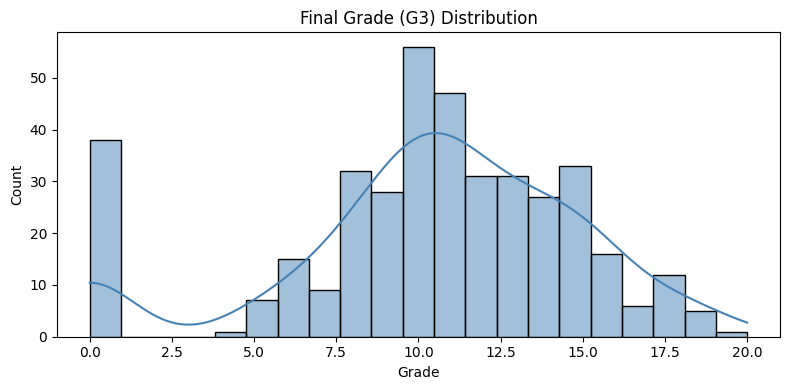

In [5]:
# how are final grades distributed?
plt.figure(figsize=(8, 4))
sns.histplot(df['G3'], bins=21, kde=True, color='steelblue')
plt.title('Final Grade (G3) Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150)
plt.show()

pass
1    265
0    130
Name: count, dtype: int64
pass rate: 67.1%


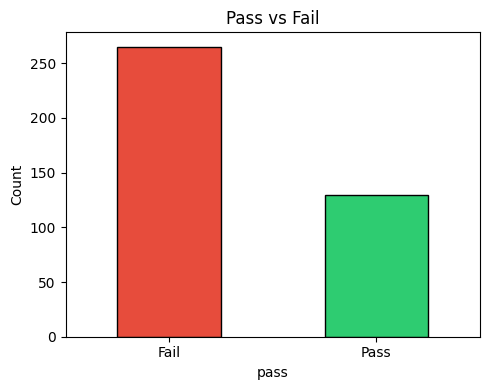

In [6]:
# binarise - pass if G3 >= 10, else fail
df['pass'] = (df['G3'] >= 10).astype(int)
print(df['pass'].value_counts())
print(f"pass rate: {df['pass'].mean()*100:.1f}%")

plt.figure(figsize=(5, 4))
df['pass'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)
plt.title('Pass vs Fail')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('pass_fail_dist.png', dpi=150)
plt.show()

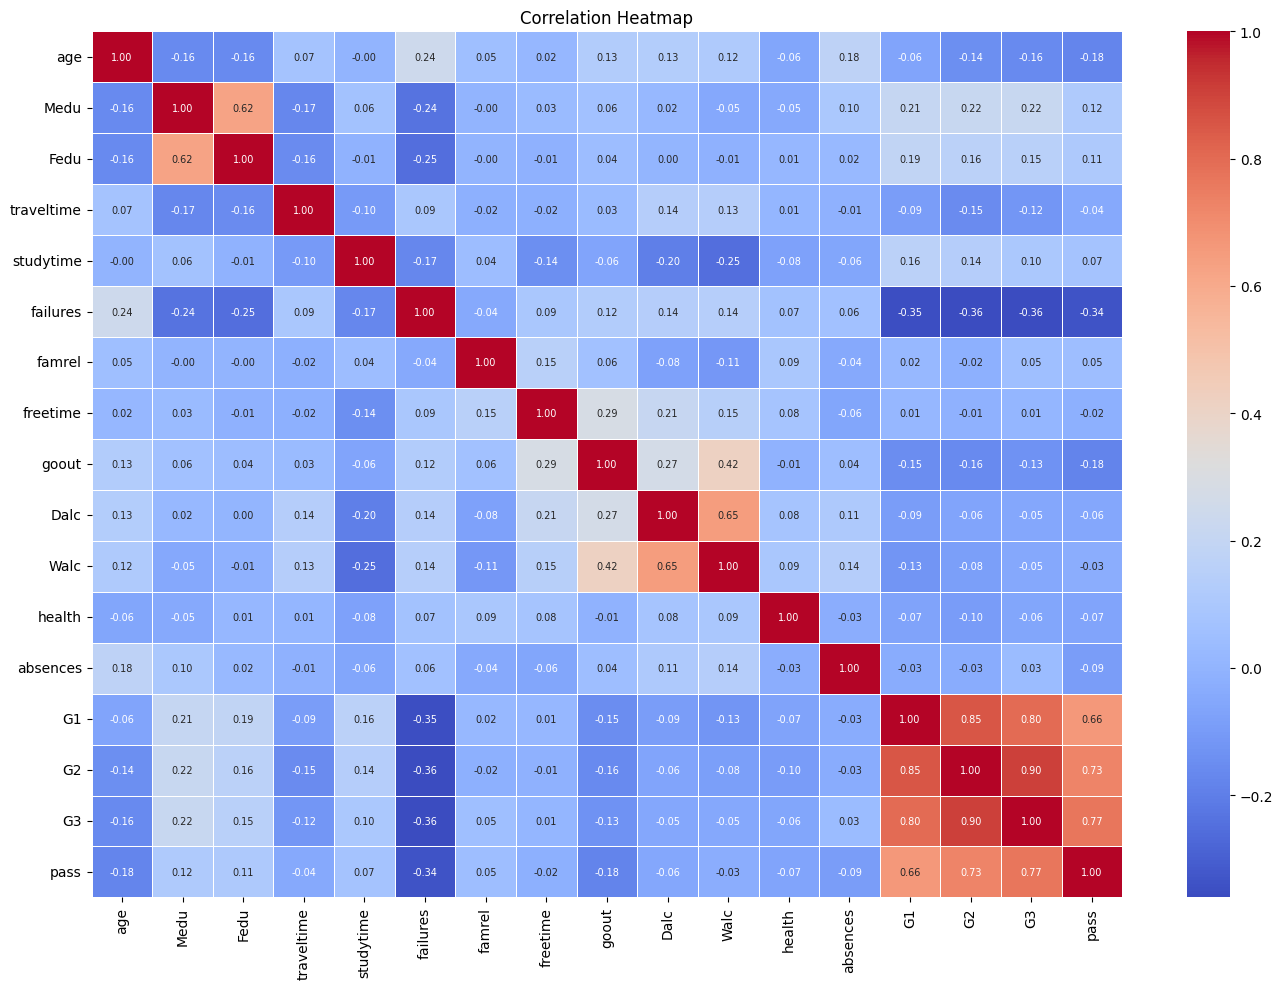

In [7]:
# correlation heatmap across numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

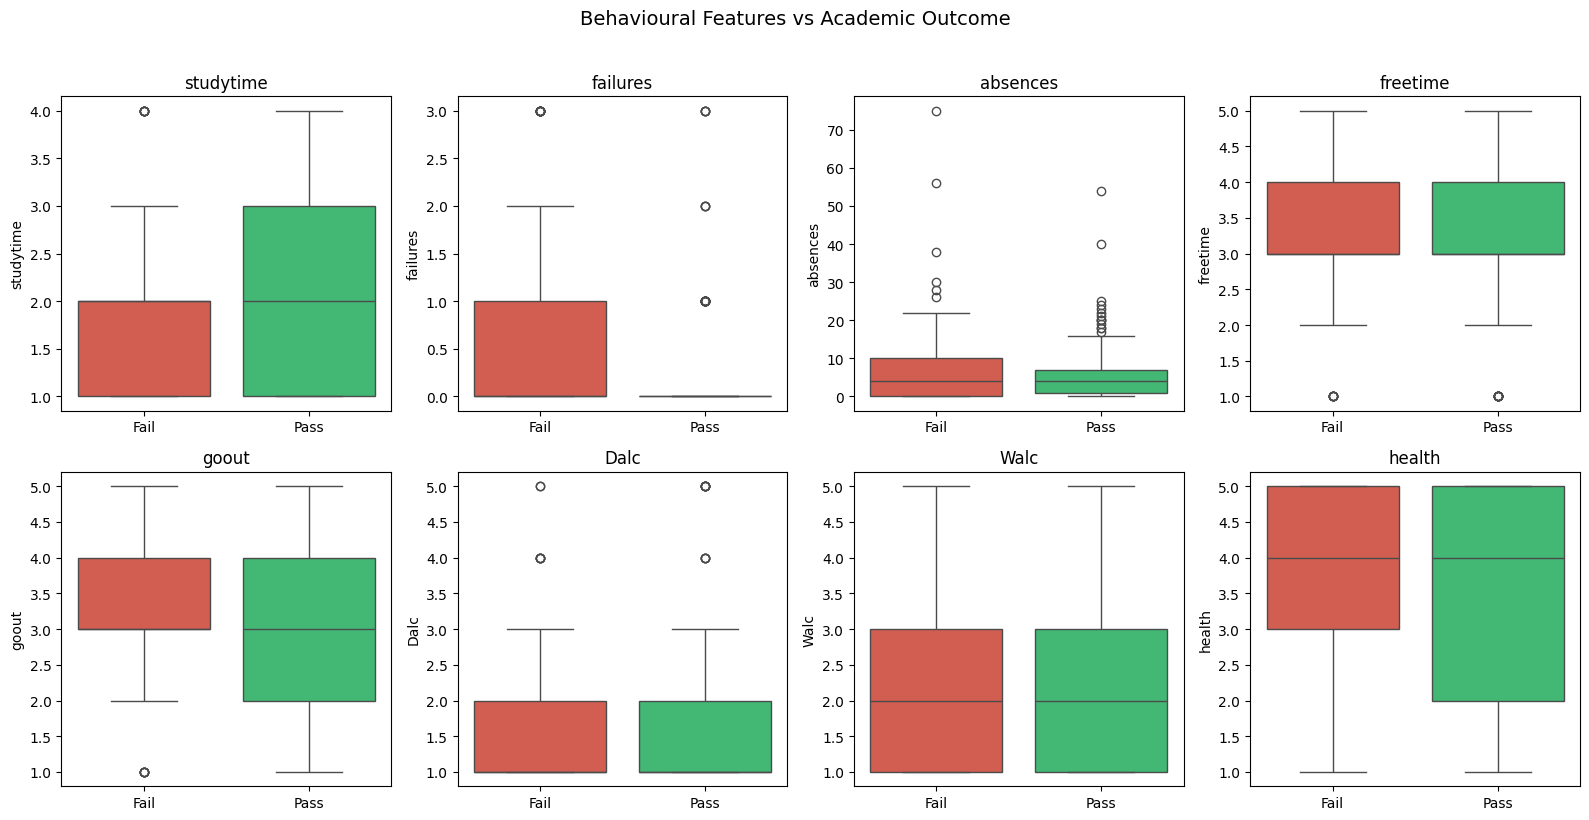

In [8]:
behavioural = ['studytime', 'failures', 'absences', 'freetime',
               'goout', 'Dalc', 'Walc', 'health']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(behavioural):
    sns.boxplot(x='pass', y=col, data=df, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Fail', 'Pass'])
    axes[i].set_xlabel('')

plt.suptitle('Behavioural Features vs Academic Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('behavioural_features.png', dpi=150)
plt.show()

##  Preprocessing

In [9]:
df_enc = df.copy()
cat_cols = df_enc.select_dtypes(include='object').columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

print("categorical columns encoded:", cat_cols)

categorical columns encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [10]:
# dropping G1, G2, G3 — they'd be direct leakage since pass is derived from G3
X = df_enc.drop(columns=['G1', 'G2', 'G3', 'pass'])
y = df_enc['pass']

print("features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
X shape: (395, 30) | y shape: (395,)


In [11]:
# stratified split so class ratio stays consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"train pass rate: {y_train.mean():.2%} | test pass rate: {y_test.mean():.2%}")

train: 316 | test: 79
train pass rate: 67.09% | test pass rate: 67.09%


##  Random Forest

In [12]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("best params:", grid_rf.best_params_)
print("best CV F1:", round(grid_rf.best_score_, 4))

best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
best CV F1: 0.8192


In [13]:
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {acc_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

Accuracy : 0.7089
F1 Score : 0.8067
ROC-AUC  : 0.6154
              precision    recall  f1-score   support

        Fail       0.62      0.31      0.41        26
        Pass       0.73      0.91      0.81        53

    accuracy                           0.71        79
   macro avg       0.67      0.61      0.61        79
weighted avg       0.69      0.71      0.68        79



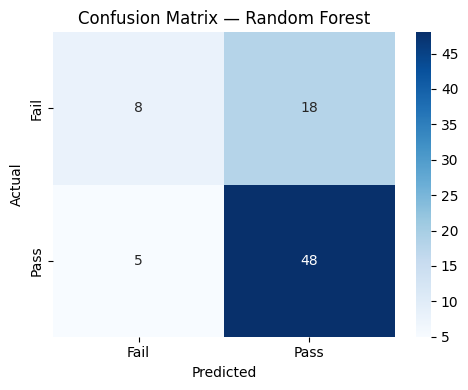

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=150)
plt.show()

##  XGBoost

In [15]:
# scale_pos_weight handles class imbalance in XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [scale_pos]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid_xgb, cv=5, scoring='f1', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

print("best params:", grid_xgb.best_params_)
print("best CV F1:", round(grid_xgb.best_score_, 4))

best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': np.float64(0.49056603773584906)}
best CV F1: 0.7599


In [16]:
xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {acc_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {auc_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Fail', 'Pass']))

Accuracy : 0.6329
F1 Score : 0.7290
ROC-AUC  : 0.5711
              precision    recall  f1-score   support

        Fail       0.44      0.42      0.43        26
        Pass       0.72      0.74      0.73        53

    accuracy                           0.63        79
   macro avg       0.58      0.58      0.58        79
weighted avg       0.63      0.63      0.63        79



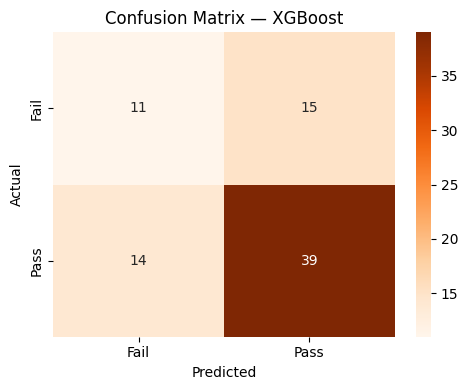

In [17]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_xgb.png', dpi=150)
plt.show()

##  Model Comparison

In [18]:
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost'],
    'Accuracy': [acc_rf, acc_xgb],
    'F1 Score': [f1_rf, f1_xgb],
    'ROC-AUC':  [auc_rf, auc_xgb]
}).set_index('Model').round(4)
print(results)

               Accuracy  F1 Score  ROC-AUC
Model                                     
Random Forest    0.7089    0.8067   0.6154
XGBoost          0.6329    0.7290   0.5711


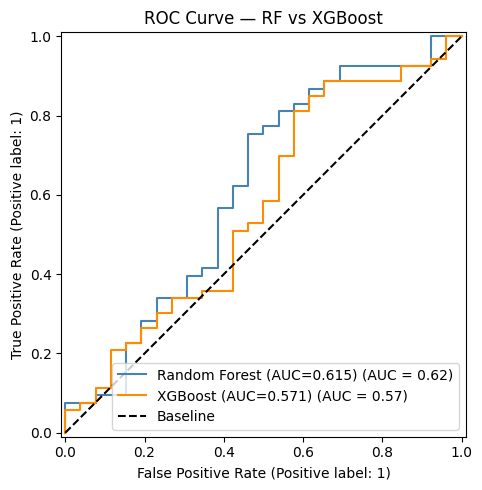

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  name=f'Random Forest (AUC={auc_rf:.3f})',  ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name=f'XGBoost (AUC={auc_xgb:.3f})', ax=ax, color='darkorange')
ax.plot([0, 1], [0, 1], 'k--', label='Baseline')
ax.set_title('ROC Curve — RF vs XGBoost')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

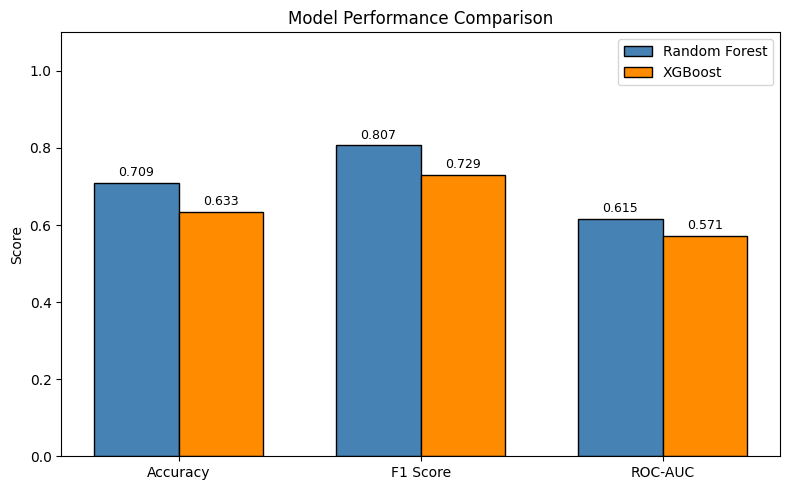

In [20]:
metrics  = ['Accuracy', 'F1 Score', 'ROC-AUC']
rf_vals  = [acc_rf, f1_rf, auc_rf]
xgb_vals = [acc_xgb, f1_xgb, auc_xgb]
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, rf_vals,  w, label='Random Forest', color='steelblue',  edgecolor='black')
b2 = ax.bar(x + w/2, xgb_vals, w, label='XGBoost',       color='darkorange', edgecolor='black')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

##  SHAP Explainability

I'm using SHAP here to understand *why* the model makes each prediction, not just what it predicts.
This is the part that actually makes the "personalised pathway" angle meaningful.

In [21]:
explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# using class 1 (Pass) SHAP values
shap_pass = shap_values[:, :, 1] if not isinstance(shap_values, list) else shap_values[1]
print("shap values ready, shape:", shap_pass.shape)

shap values ready, shape: (79, 30)


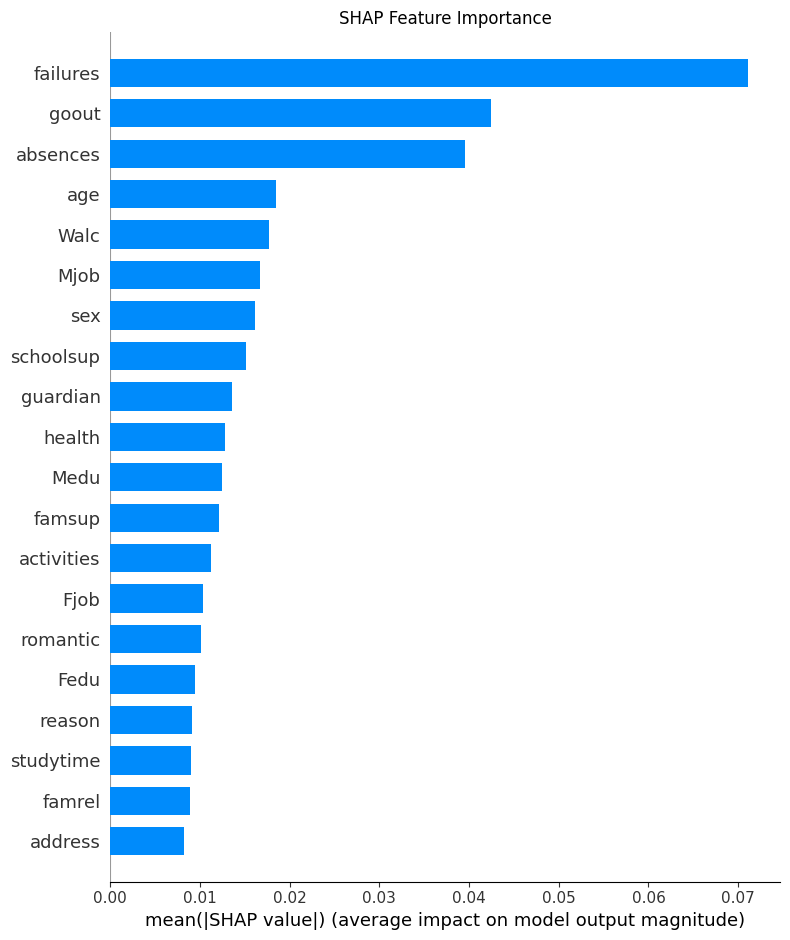

In [22]:
# which features matter most overall?
plt.figure()
shap.summary_plot(shap_pass, X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

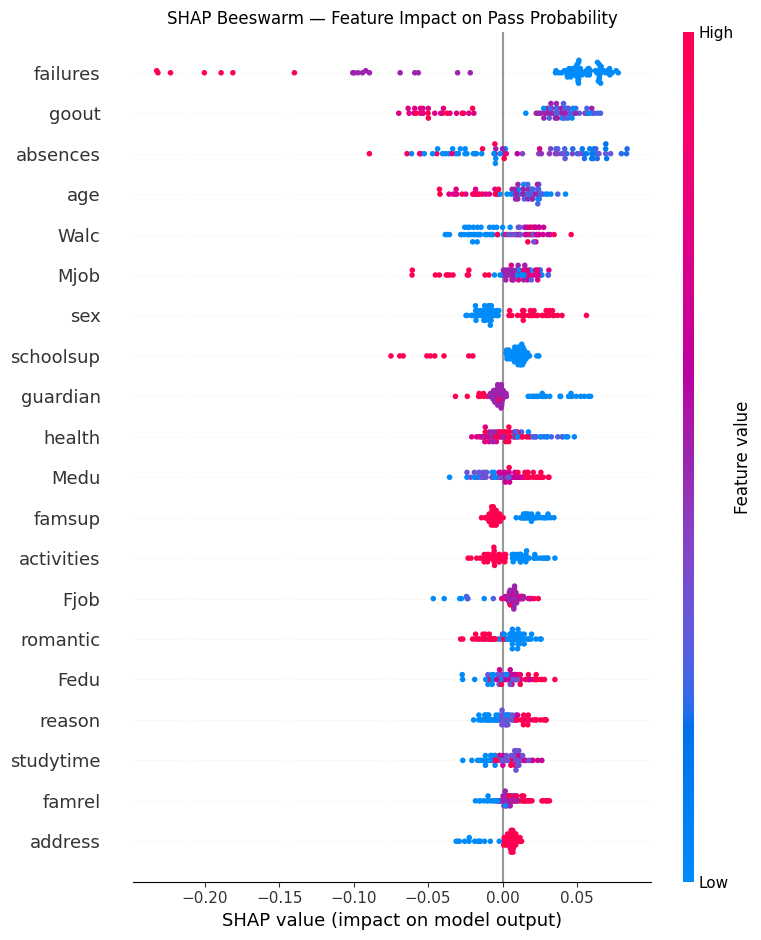

In [23]:
# beeswarm shows direction too - high/low feature value pushing pass prob up or down
plt.figure()
shap.summary_plot(shap_pass, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Beeswarm — Feature Impact on Pass Probability')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Student 0 | Actual: Pass | Predicted: Pass


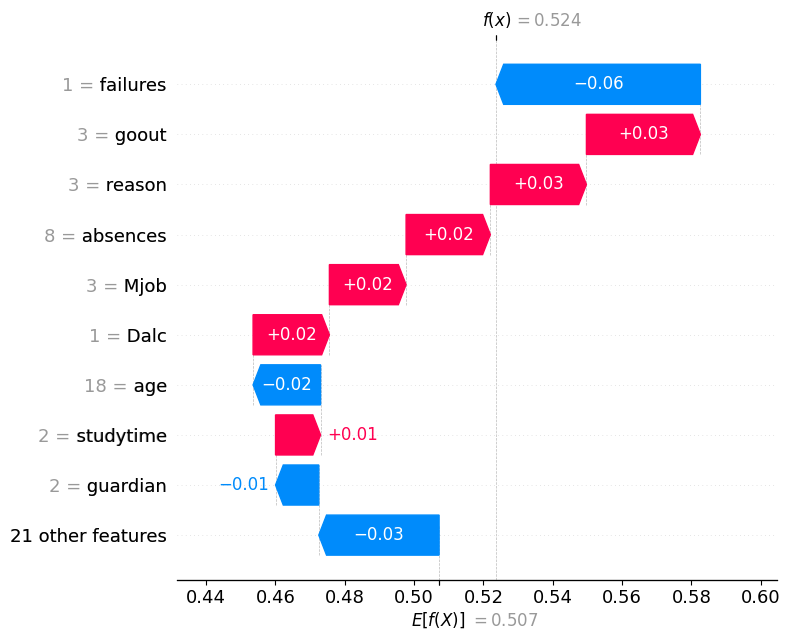

In [24]:
# waterfall plot for one student
student_idx = 0
print(f"Student {student_idx} | Actual: {'Pass' if y_test.iloc[student_idx]==1 else 'Fail'} "
      f"| Predicted: {'Pass' if y_pred_rf[student_idx]==1 else 'Fail'}")

single_student = X_test.iloc[[student_idx]]
sv_single = explainer(single_student)

# shape is (1, 30, 2) — index [0, :, 1] to get class=Pass explanation
shap.plots.waterfall(sv_single[0, :, 1], show=False)
plt.tight_layout()
plt.savefig('force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

##  Personalised Intervention Engine

I built this function to translate SHAP values into actual recommendations.
For each at-risk student, it tells you which behaviours are pulling them down
and what specific intervention to suggest - that's the personalised pathway part.

In [25]:
def generate_intervention(student_features, model, explainer, feature_names):
    student_arr = student_features.values.reshape(1, -1)
    pred = model.predict(student_arr)[0]
    prob = model.predict_proba(student_arr)[0][1]

    sv = explainer.shap_values(student_arr)  # shape (1, 30, 2)
    sv_class1 = sv[0, :, 1]                  # grab class=Pass, all 30 features

    risk_idx  = np.argsort(sv_class1)[:3]
    boost_idx = np.argsort(sv_class1)[-3:][::-1]

    risk_factors  = [(feature_names[int(i)], round(float(sv_class1[i]), 4)) for i in risk_idx]
    boost_factors = [(feature_names[int(i)], round(float(sv_class1[i]), 4)) for i in boost_idx]

    tips = {
            'studytime': 'Increase weekly study hours.',
            'failures':  'Enrol in remedial or tutoring support.',
            'absences':  'Attendance monitoring and counselling needed.',
            'freetime':  'Structure free time with academic activities.',
            'goout':     'Balance social outings with study schedule.',
            'Dalc':      'Weekday alcohol use — refer for counselling.',
            'Walc':      'Weekend alcohol use — refer for counselling.',
            'health':    'Coordinate with school health officer.',
            'famrel':    'Family counsellor involvement recommended.',
            'internet':  'Direct to school digital resource centre.',
            'romantic':  'Romantic distraction — provide counselling.',
            }

    return {
            'prediction':    'Pass' if pred == 1 else 'Fail',
            'pass_prob':     round(prob, 4),
            'risk_factors':  risk_factors,
            'boost_factors': boost_factors,
            'interventions': [tips[f] for f, _ in risk_factors if f in tips] or ['No critical risk factors.']
            }

In [26]:
# running it on the first 3 students the model flagged as at-risk
at_risk_idx = np.where(y_pred_rf == 0)[0][:3]

for idx in at_risk_idx:
    result = generate_intervention(X_test.iloc[idx], rf_best, explainer, X.columns.tolist())
    print(f"\n{'='*55}")
    print(f"Student {idx} | Predicted: {result['prediction']} | Pass Prob: {result['pass_prob']}")
    print("\nRisk Factors (SHAP):")
    for feat, val in result['risk_factors']:
        print(f"  - {feat}: {val}")
    print("\nRecommended Interventions:")
    for tip in result['interventions']:
        print(f"  → {tip}")


Student 7 | Predicted: Fail | Pass Prob: 0.4323

Risk Factors (SHAP):
  - goout: -0.0594
  - failures: -0.0302
  - Mjob: -0.0229

Recommended Interventions:
  → Balance social outings with study schedule.
  → Enrol in remedial or tutoring support.

Student 14 | Predicted: Fail | Pass Prob: 0.4498

Risk Factors (SHAP):
  - failures: -0.0971
  - goout: -0.0535
  - traveltime: -0.0193

Recommended Interventions:
  → Enrol in remedial or tutoring support.
  → Balance social outings with study schedule.

Student 16 | Predicted: Fail | Pass Prob: 0.3095

Risk Factors (SHAP):
  - failures: -0.2314
  - absences: -0.0239
  - goout: -0.0201

Recommended Interventions:
  → Enrol in remedial or tutoring support.
  → Attendance monitoring and counselling needed.
  → Balance social outings with study schedule.


##  Cross-Validation

In [27]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf  = cross_val_score(rf_best,  X, y, cv=skf, scoring='f1')
cv_xgb = cross_val_score(xgb_best, X, y, cv=skf, scoring='f1')

print(f"RF  CV F1: {cv_rf.round(4)}  | mean: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"XGB CV F1: {cv_xgb.round(4)} | mean: {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

RF  CV F1: [0.7931 0.8403 0.8136 0.7833 0.8421]  | mean: 0.8145 ± 0.0239
XGB CV F1: [0.7706 0.7103 0.7706 0.7091 0.8077] | mean: 0.7537 ± 0.0384


##  Final Summary

In [30]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"{'Metric':<20} {'Random Forest':>15} {'XGBoost':>15}")
print("-" * 60)
print(f"{'Accuracy':<20} {acc_rf:>15.4f} {acc_xgb:>15.4f}")
print(f"{'F1 Score':<20} {f1_rf:>15.4f} {f1_xgb:>15.4f}")
print(f"{'ROC-AUC':<20} {auc_rf:>15.4f} {auc_xgb:>15.4f}")
print(f"{'CV F1 Mean':<20} {cv_rf.mean():>15.4f} {cv_xgb.mean():>15.4f}")
print("=" * 60)

best = 'Random Forest' if auc_rf >= auc_xgb else 'XGBoost'
print(f"\n{best} came out on top based on ROC-AUC.")
print("SHAP confirmed that failures, goout, and absences")
print("are the biggest drivers - which maps directly to the")
print("personalised intervention recommendations above.")

FINAL RESULTS
Metric                 Random Forest         XGBoost
------------------------------------------------------------
Accuracy                      0.7089          0.6329
F1 Score                      0.8067          0.7290
ROC-AUC                       0.6154          0.5711
CV F1 Mean                    0.8145          0.7537

Random Forest came out on top based on ROC-AUC.
SHAP confirmed that failures, goout, and absences
are the biggest drivers - which maps directly to the
personalised intervention recommendations above.


In [29]:
from google.colab import files
files.download('student-mat.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
from getpass import getpass
drive.mount('/content/drive')

token = getpass("GitHub token: ")

!git config --global user.email "manikantmgr14@gmail.com"
!git config --global user.name "Manikant-14"

%cd /content
!git clone https://{token}@github.com/Manikant-14/Student_Performance_Predictor.git

Mounted at /content/drive
GitHub token: ··········
/content
Cloning into 'Student_Performance_Predictor'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.


In [ ]:
!cp -r "/content/drive/MyDrive/Student_Performance_Predictor/." /content/Student_Performance_Predictor/

%cd /content/Student_Performance_Predictor
!ls -la

!git add .
!git commit -m "Initial commit: notebook, data, report, README"
!git branch -M main
!git push -u origin main